Linear Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

Gradient Descent হলো এমন একটি algorithm যা loss কমানোর জন্য weight ও bias ধাপে ধাপে update করে optimal solution-এর দিকে নিয়ে যায়।

dw = 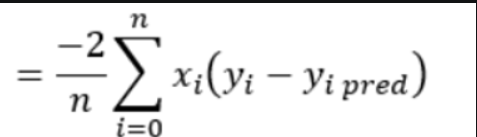

db = 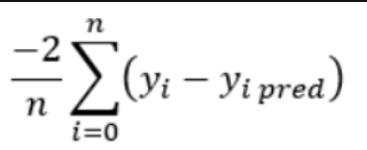

1.Initialize w,b

2.Predict
      
3.Calculate Error
      
4.Calculate dw,db
      
5.Update w,b
      
6.Repeat
      
7.Loss কমতে কমতে Minimum এ পৌঁছায়
      
8.Best w,b পাওয়া যায়

In [11]:
import numpy as np

In [13]:
class Linear_Regression():

    def __init__(self , learning_rate , no_of_iterations):
        self.learing_rate = learning_rate
        self.no_of_iterations = no_of_iterations

     # fit function to train the model
    def fit(self ,X,Y):

       # no_of_training_examples, no_of_features
        self.m , self.n = X.shape
          
       # initiating the weight and bias
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

       # implementing Gradient Descent for Optimization
        for i in range(self.no_of_iterations):
           self.update_weights()
    
    # function to update weights in gradient descent
    def update_weights(self):
         Y_prediction = self.predict(self.X)


          # calculate gradients  
         dw = -(2* (self.X.T).dot(self.Y - Y_prediction))/self.m
         db = -2* np.sum(self.Y - Y_prediction)/self.m

        # updating the weights
         self.w = self.w - self.learing_rate*dw
         self.b = self.b  - self.learing_rate*db
    
        # Line function for prediction:
    def predict(self,X):
        return X.dot(self.w) + self.b
    


In [1]:
# importing the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('E:/ML/salary_data (1).csv')

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [5]:
X = df.iloc[: , : -1].values
Y = df.iloc[: , 1].values

In [6]:
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [8]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state = 2)

Training the Regression model

In [14]:
model = Linear_Regression(learning_rate= 0.02 , no_of_iterations= 1000)

In [15]:
model.fit(X_train , Y_train)

In [16]:
# printing the parameter values ( weights & bias)
print('weight = ', model.w[0])
print('bias = ', model.b)

weight =  9514.400999035135
bias =  23697.406507136307


y = 9514(x) + 23697

salary = 9514(experience) + 23697

Predict the salary value for test data

In [18]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


Visualizing the predicted values & actual Values

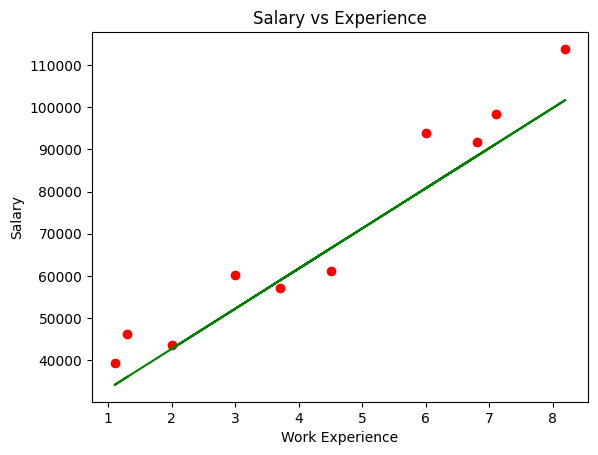

In [19]:
plt.scatter(X_test , Y_test , color ='red')
plt.plot(X_test , test_data_prediction , color ='green')
plt.xlabel('Work Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()